In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikealt
import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.25 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...


In [2]:
#Test ModeSelector directly
traj = waveform_gen_comb.waveform_generator.inspiral_generator
amp = waveform_gen_comb.waveform_generator.amplitude_generator
ylm_gen = waveform_gen_comb.waveform_generator.ylm_gen

N_traj = 5000
delta_T = T * YRSID_SI / N_traj

mode_selector = modeselectoralt.ModeSelector(params_star, traj, amp, ylm_gen, delta_T, gwf, verbose=True)

n_vals = np.arange(-1, 3)
ell = 2

selected_modes, selected_labels = mode_selector.select_modes(M_sel=None, n_vals=n_vals, ell=ell)

print(f"\nSelected {len(selected_modes)} mode groups:")
for i, (modes, labels) in enumerate(zip(selected_modes, selected_labels)):
    print(f"  n={labels[0][2]}: {len(labels)} modes - {labels}")

Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]]

Selected 4 mode groups:
  n=-1: 5 modes - [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]
  n=0: 5 modes - [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]
  n=1: 5 modes - [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]
  n=2: 5 modes - [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]


In [3]:
snr_per_group = []
for modes, labels in zip(selected_modes, selected_labels):
    snr = mode_selector.SNR_approx(modes)
    # Convert to float if CuPy array
    if hasattr(snr, 'get'):
        snr = float(snr.get())
    else:
        snr = float(snr)
    snr_per_group.append(snr)
    print(f"n={labels[0][2]:2d}: SNR = {snr:.4f}")

total_snr = np.sqrt(np.sum(np.array(snr_per_group)**2))
print(f"\nTotal SNR: {total_snr:.4f}")

n=-1: SNR = 2.1522
n= 0: SNR = 1.7121
n= 1: SNR = 2.1522
n= 2: SNR = 2.1596

Total SNR: 4.1060


/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/lisatools/sensitivity.py:495: RuntimeWarning: divide by zero encountered in divide
  Poms = ((1.5e-11) * (1.5e-11)) * (1 + np.power((2e-3) / f, 4))
/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/lisatools/sensitivity.py:501: RuntimeWarning: divide by zero encountered in divide
  * (1 + (4e-4 / f) * (4e-4 / f))
/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/lisatools/sensitivity.py:515: RuntimeWarning: divide by zero encountered in power
  * np.power(f, -7 / 3)


In [4]:
#Test LogLike
loglike_obj = loglikealt.LogLike(params_star, waveform_gen_comb, gwf, 
                                  verbose=True, waveform_gen_sep=waveform_gen_sep,
                                  ell=2, n_vals=np.arange(-1, 3), M_mode=None,
                                  )

print(f"\nSelected modes: {loglike_obj.selected_labels}")

Delta_T for mode selection: 525.9691627257598 seconds
Generating modes at initialization...
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]]
Number of selected modes: 4
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1), (2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0), (2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1), (2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]
Selected modes structure: [[54, 1053, 1164, 7047, 7158], [55, 1054, 1165, 7048, 7159], [56, 1055, 1166, 7

In [5]:
# Cell 8: Evaluate at true parameters
logl_true = loglike_obj(params_star)
data_snr = gwf.rhostat(loglike_obj.signal)

print(f"Log-likelihood at true params: {logl_true:.6f}")
print(f"Data SNR: {data_snr:.4f}")

Evaluating log-likelihood at parameters: (1000000.0, 30.0, 0.7, 15, 0.4, 1.0, 0.25, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.0, 0.5)
Using selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]]
Waveform amplitudes:
  Mode 0: max(|h|) = 5.358086279269143e-22, <hf|hf> = 1.7396262545232943, rho = 1.3189489203617002
  Mode 1: max(|h|) = 4.891370140818389e-22, <hf|hf> = 0.5885882411059205, rho = 0.767195047628646
  Mode 2: max(|h|) = 3.512794501818367e-22, <hf|hf> = 0.09523008435468815, rho = 0.3085937205367085
  Mode 3: max(|h|) = 3.3585553304771773e-23, <hf|hf> = 0.002746932283895805, rho = 0.05241118472135318
Individual rho values: [1.31894892 0.76719505 0.30859372 0.05241118]
Max rho: 1.3189489203617002, Min rho: 0.05241118472135318
Dominant mode rho (first): 1.3189489203617002
Actually dom

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikegen
import modeselector
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.25 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# NOTE: change verbose argument for debugging
loglike_obj = loglikegen.LogLike(params_star, 
                                   waveform_gen_comb, 
                                   gwf, 
                                   mode_select = [(2, -2, 0), (2, -2, -1), (2, -2, 1), (3, -3, -1), (3, -3, 1)],
                                   verbose=False, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   )

print('Done initializing loglike class.')
print("Setting up log_density and prior functions...")
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


with open('cov_matrix_2yr.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

sigmas = np.sqrt(np.diag(cov_matrix))
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike

    return log_likes

def prior_transform(u):
    n=int(1e4)
    logm1lim = [param_true[0] - n*sigmas[0], param_true[0] + n*sigmas[0]]
    logm2lim = [param_true[1] - n*sigmas[1], param_true[1] + n*sigmas[1]]
    alim = [max(param_true[2] - n*sigmas[2], 0.0), min(param_true[2] + n*sigmas[2], 0.999)]
    p0lim = [param_true[3] - n*sigmas[3], param_true[3] + n*sigmas[3]]
    e0lim = [param_true[4] - n*sigmas[4], param_true[4] + n*sigmas[4]]

    
    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    
print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Setting up log_density and prior functions...
Calculating SNR...
SNR calculated: 5.283339408229159
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


GENERATING DATA WAVEFORM
Data waveform shape: (262985,)
Data waveform type: <class 'cupy.ndarray'>
Data: 262985 samples = 2629850.0s

TEMPLATE 1 (PROC1)
Δparams from true: [ 0.02680358 -0.00729519  0.0897165  -0.60320453 -0.00172013]
Step 1: Lengths - Data: 262985, Template: 262985
Max correlation: 2.163e-37 at τ=0.0s (idx=0)
Optimal phase: -0.7°

TEMPLATE 2 (PROC2)
Δparams from true: [-0.06154045  0.02794052 -0.24209423  1.56223858 -0.00197099]
Step 1: Lengths - Data: 262985, Template: 262985
Max correlation: 2.078e-37 at τ=0.0s (idx=0)
Optimal phase: -0.4°


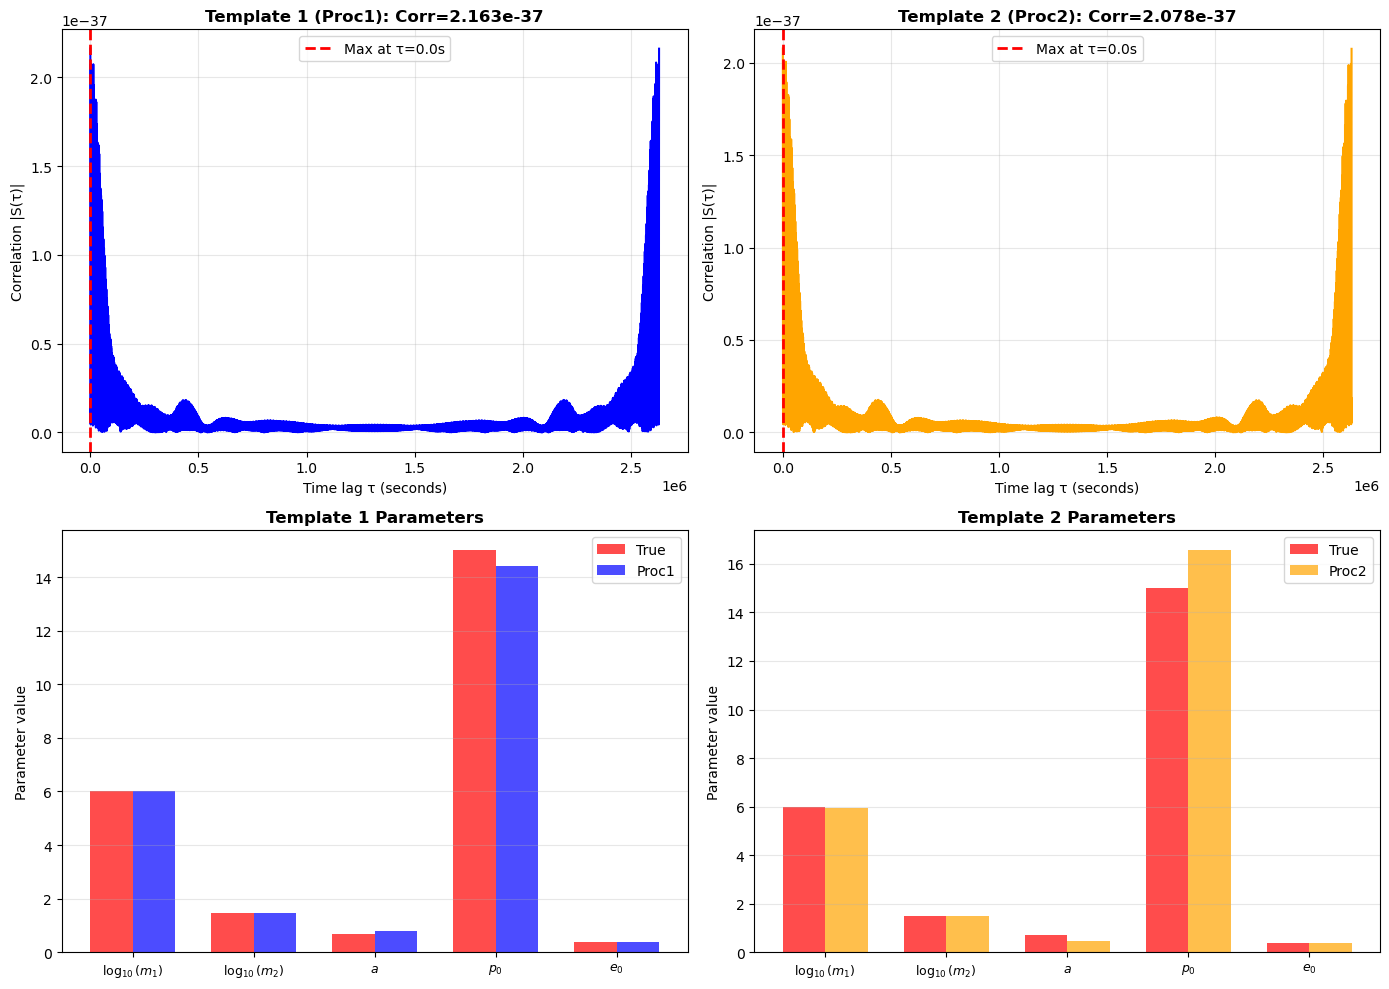


SUMMARY
Template 1 (Proc1): Correlation = 2.163e-37, τ = 0.0s, φ = -0.7°
Template 2 (Proc2): Correlation = 2.078e-37, τ = 0.0s, φ = -0.4°

Better match: Template 1 (Proc1)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def find_max_inner_product_fft_gw(d, h, dt=1.0, verbose=True):
    """
    Find time lag τ and phase that maximizes inner product <d(t)|h(t-τ)> using FFT.
    For gravitational waves: h = h_plus + i*h_cross (or combined complex waveform)
    """
    # Step 1: Zero padding
    n = max(len(d), len(h))
    h_pad = np.pad(h, (0, n - len(h)), mode='constant')
    d_pad = np.pad(d, (0, n - len(d)), mode='constant')
    
    if verbose:
        print(f"Step 1: Lengths - Data: {len(d_pad)}, Template: {len(h_pad)}")
    
    # Step 2: FFT
    H = np.fft.fft(h_pad)
    D = np.fft.fft(d_pad)
    
    # Step 3: Y = D × H* (conjugate multiplication)
    Y = D * np.conj(H)
    
    # Step 4: IFFT and find maximum
    S = np.fft.ifft(Y)
    S_abs = np.abs(S)
    
    idx_max = np.argmax(S_abs)
    max_correlation = S_abs[idx_max]
    phase_max = np.angle(S[idx_max])
    tau_max = idx_max * dt
    
    if verbose:
        print(f"Max correlation: {max_correlation:.3e} at τ={tau_max:.1f}s (idx={idx_max})")
        print(f"Optimal phase: {np.degrees(phase_max):.1f}°")
    
    return tau_max, phase_max, max_correlation, S_abs


# Test parameters
param_true = np.array([6., 1.47712125, 0.7, 15., 0.4])
proc1_params = np.array([6.02680358, 1.46982606, 0.7897165, 14.39679547, 0.39827987])
proc2_params = np.array([5.93845955, 1.50506177, 0.45790577, 16.56223858, 0.39802901])

# Generate data waveform (TRUE signal)
print("="*70)
print("GENERATING DATA WAVEFORM")
print("="*70)
m1_true, m2_true, a_true, p0_true, e0_true = 10**param_true[0], 10**param_true[1], param_true[2], param_true[3], param_true[4]

data_waveform = waveform_gen_comb(
    m1_true, m2_true, a_true, p0_true, e0_true, xI0, dist,
    qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

# Check shape and convert to numpy if needed
print(f"Data waveform shape: {data_waveform.shape}")
print(f"Data waveform type: {type(data_waveform)}")

# Convert CuPy to NumPy if needed
if hasattr(data_waveform, 'get'):
    data_waveform = data_waveform.get()

# Handle 1D complex array vs 2D [h+, hx] array
if data_waveform.ndim == 1:
    # Already complex
    data_complex = data_waveform
elif data_waveform.ndim == 2:
    # Two polarizations: combine as h = h_plus + i*h_cross
    data_complex = data_waveform[:, 0] + 1j * data_waveform[:, 1]
else:
    raise ValueError(f"Unexpected waveform shape: {data_waveform.shape}")

print(f"Data: {len(data_complex)} samples = {len(data_complex)*dt:.1f}s")

# Generate template 1 (proc1)
print("\n" + "="*70)
print("TEMPLATE 1 (PROC1)")
print("="*70)
m1_1, m2_1, a_1, p0_1, e0_1 = 10**proc1_params[0], 10**proc1_params[1], proc1_params[2], proc1_params[3], proc1_params[4]
print(f"Δparams from true: {proc1_params - param_true}")

template1 = waveform_gen_comb(
    m1_1, m2_1, a_1, p0_1, e0_1, xI0, dist,
    qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

# Convert to numpy
if hasattr(template1, 'get'):
    template1 = template1.get()

# Handle shape
if template1.ndim == 1:
    template1_complex = template1
elif template1.ndim == 2:
    template1_complex = template1[:, 0] + 1j * template1[:, 1]

tau1, phase1, corr1, S1 = find_max_inner_product_fft_gw(data_complex, template1_complex, dt=dt)

# Generate template 2 (proc2)
print("\n" + "="*70)
print("TEMPLATE 2 (PROC2)")
print("="*70)
m1_2, m2_2, a_2, p0_2, e0_2 = 10**proc2_params[0], 10**proc2_params[1], proc2_params[2], proc2_params[3], proc2_params[4]
print(f"Δparams from true: {proc2_params - param_true}")

template2 = waveform_gen_comb(
    m1_2, m2_2, a_2, p0_2, e0_2, xI0, dist,
    qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

# Convert to numpy
if hasattr(template2, 'get'):
    template2 = template2.get()

# Handle shape
if template2.ndim == 1:
    template2_complex = template2
elif template2.ndim == 2:
    template2_complex = template2[:, 0] + 1j * template2[:, 1]

tau2, phase2, corr2, S2 = find_max_inner_product_fft_gw(data_complex, template2_complex, dt=dt)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Template 1 correlation
time_lags = np.arange(len(S1)) * dt
axes[0, 0].plot(time_lags, S1, 'b-', linewidth=1.5)
axes[0, 0].axvline(tau1, color='red', linestyle='--', linewidth=2, label=f'Max at τ={tau1:.1f}s')
axes[0, 0].set_xlabel('Time lag τ (seconds)')
axes[0, 0].set_ylabel('Correlation |S(τ)|')
axes[0, 0].set_title(f'Template 1 (Proc1): Corr={corr1:.3e}', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Template 2 correlation
axes[0, 1].plot(time_lags, S2, 'orange', linewidth=1.5)
axes[0, 1].axvline(tau2, color='red', linestyle='--', linewidth=2, label=f'Max at τ={tau2:.1f}s')
axes[0, 1].set_xlabel('Time lag τ (seconds)')
axes[0, 1].set_ylabel('Correlation |S(τ)|')
axes[0, 1].set_title(f'Template 2 (Proc2): Corr={corr2:.3e}', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Parameter comparison - Template 1
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
x = np.arange(5)
width = 0.35
axes[1, 0].bar(x - width/2, param_true, width, label='True', color='red', alpha=0.7)
axes[1, 0].bar(x + width/2, proc1_params, width, label='Proc1', color='blue', alpha=0.7)
axes[1, 0].set_ylabel('Parameter value')
axes[1, 0].set_title('Template 1 Parameters', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels, fontsize=9)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Parameter comparison - Template 2
axes[1, 1].bar(x - width/2, param_true, width, label='True', color='red', alpha=0.7)
axes[1, 1].bar(x + width/2, proc2_params, width, label='Proc2', color='orange', alpha=0.7)
axes[1, 1].set_ylabel('Parameter value')
axes[1, 1].set_title('Template 2 Parameters', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(labels, fontsize=9)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Template 1 (Proc1): Correlation = {corr1:.3e}, τ = {tau1:.1f}s, φ = {np.degrees(phase1):.1f}°")
print(f"Template 2 (Proc2): Correlation = {corr2:.3e}, τ = {tau2:.1f}s, φ = {np.degrees(phase2):.1f}°")
print(f"\nBetter match: {'Template 1 (Proc1)' if corr1 > corr2 else 'Template 2 (Proc2)'}")

GENERATING DATA WAVEFORM
Data waveform shape: (262985,)
Data: 262985 samples = 2629850.0s
Data range: [4.426e-22, 1.947e-21]

TEMPLATE 1 (PROC1)
Δparams from true: [ 0.02680358 -0.00729519  0.0897165  -0.60320453 -0.00172013]
Template 1 range: [4.524e-22, 1.992e-21]
Step 1: Lengths - Data: 262985, Template: 262985
  Data norm: 4.606e-19
  Template norm: 4.696e-19
  After normalization - Data: 1.000e+00, Template: 1.000e+00
Step 4: Max correlation: 0.999849 at τ=0.0s (idx=0)
  Optimal phase: -0.7°

TEMPLATE 2 (PROC2)
Δparams from true: [-0.06154045  0.02794052 -0.24209423  1.56223858 -0.00197099]
Template 2 range: [4.361e-22, 1.874e-21]
Step 1: Lengths - Data: 262985, Template: 262985
  Data norm: 4.606e-19
  Template norm: 4.514e-19
  After normalization - Data: 1.000e+00, Template: 1.000e+00
Step 4: Max correlation: 0.999652 at τ=0.0s (idx=0)
  Optimal phase: -0.4°


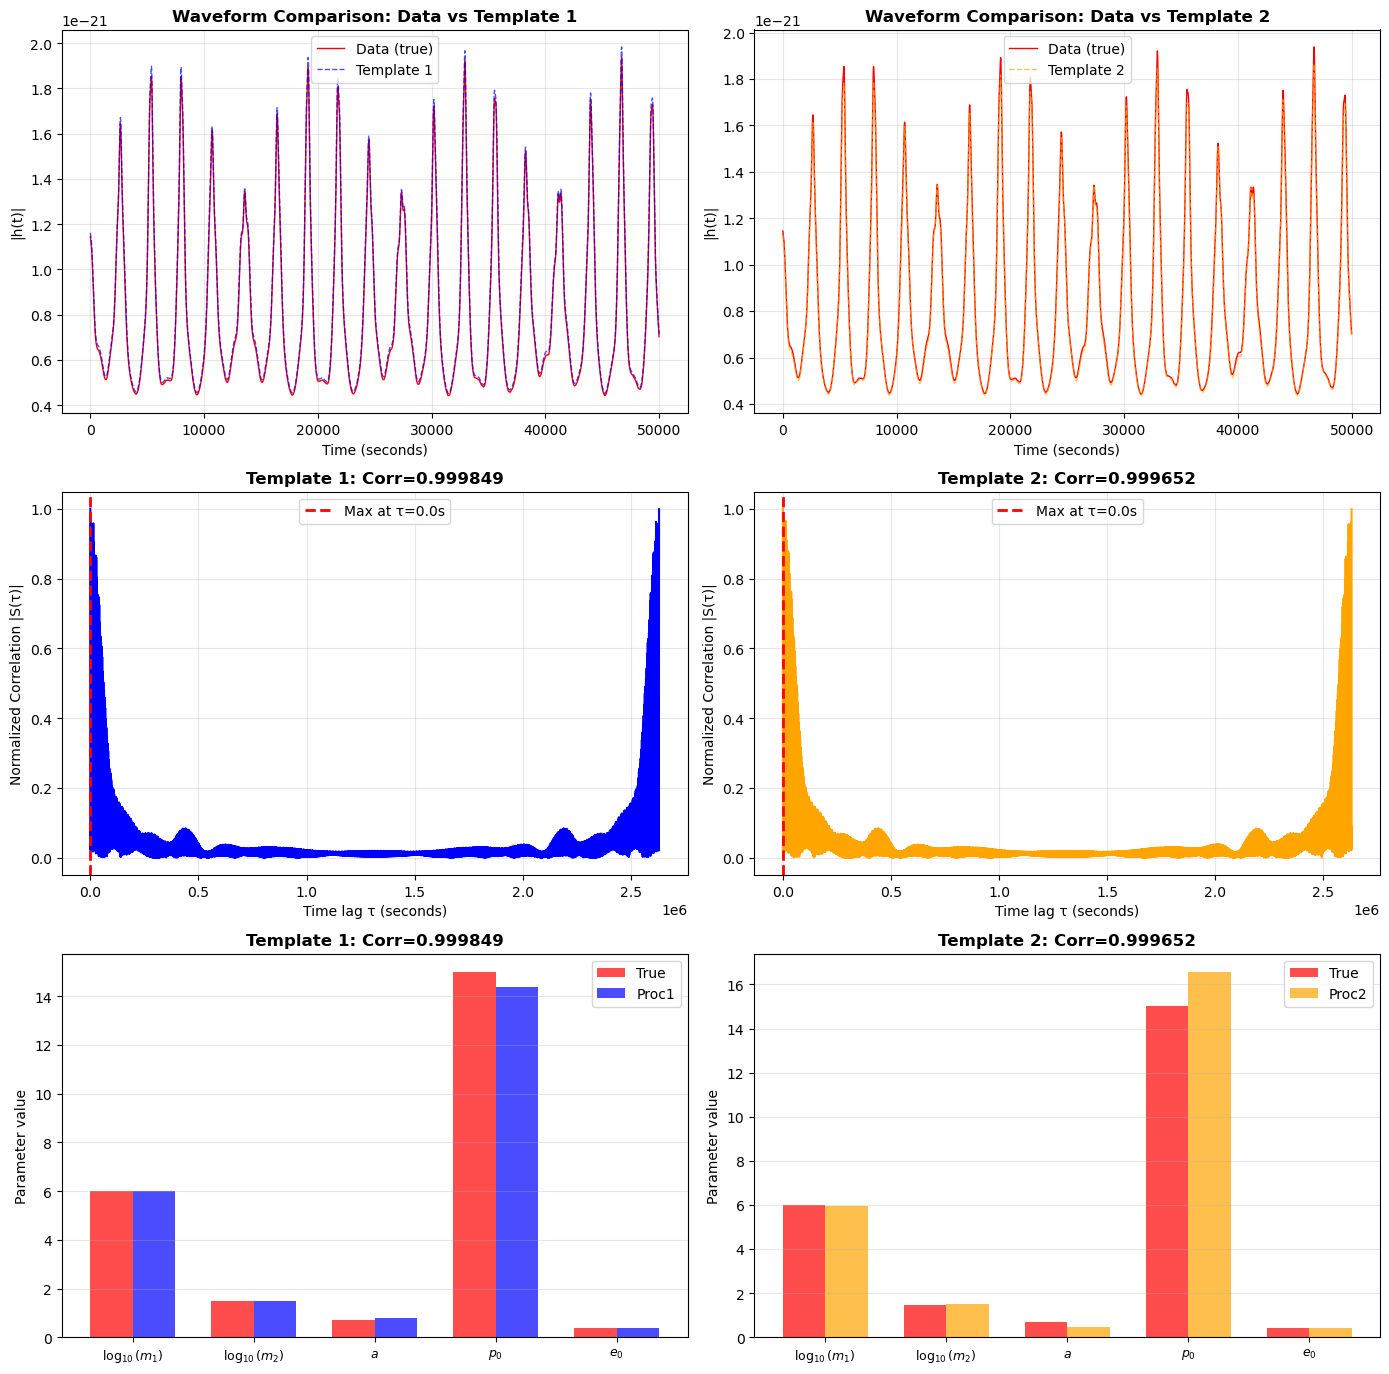


SUMMARY
Template 1 (Proc1): Correlation = 0.999849, τ = 0.0s, φ = -0.7°
Template 2 (Proc2): Correlation = 0.999652, τ = 0.0s, φ = -0.4°

Better match: Template 1 (Proc1)
Correlation difference: 0.000197

Note: Normalized correlation ranges from 0 (no match) to 1 (perfect match)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def find_max_inner_product_fft_gw(d, h, dt=1.0, normalize=True, verbose=True):
    """
    Find time lag τ and phase that maximizes inner product <d(t)|h(t-τ)> using FFT.
    
    For GW matched filtering, we typically normalize by the template norm.
    """
    # Convert to numpy if needed
    if hasattr(d, 'get'):
        d = d.get()
    if hasattr(h, 'get'):
        h = h.get()
    
    # Step 1: Zero padding
    n = max(len(d), len(h))
    h_pad = np.pad(h, (0, n - len(h)), mode='constant')
    d_pad = np.pad(d, (0, n - len(d)), mode='constant')
    
    if verbose:
        print(f"Step 1: Lengths - Data: {len(d_pad)}, Template: {len(h_pad)}")
        print(f"  Data norm: {np.linalg.norm(d_pad):.3e}")
        print(f"  Template norm: {np.linalg.norm(h_pad):.3e}")
    
    # Normalize if requested (standard for matched filtering)
    if normalize:
        d_norm = np.linalg.norm(d_pad)
        h_norm = np.linalg.norm(h_pad)
        if d_norm > 0:
            d_pad = d_pad / d_norm
        if h_norm > 0:
            h_pad = h_pad / h_norm
        if verbose:
            print(f"  After normalization - Data: {np.linalg.norm(d_pad):.3e}, Template: {np.linalg.norm(h_pad):.3e}")
    
    # Step 2: FFT
    H = np.fft.fft(h_pad)
    D = np.fft.fft(d_pad)
    
    # Step 3: Y = D × H* (conjugate multiplication)
    Y = D * np.conj(H)
    
    # Step 4: IFFT and find maximum
    S = np.fft.ifft(Y)
    S_abs = np.abs(S)
    
    idx_max = np.argmax(S_abs)
    max_correlation = S_abs[idx_max]
    phase_max = np.angle(S[idx_max])
    tau_max = idx_max * dt
    
    if verbose:
        print(f"Step 4: Max correlation: {max_correlation:.6f} at τ={tau_max:.1f}s (idx={idx_max})")
        print(f"  Optimal phase: {np.degrees(phase_max):.1f}°")
    
    return tau_max, phase_max, max_correlation, S_abs


# Test parameters
param_true = np.array([6., 1.47712125, 0.7, 15., 0.4])
proc1_params = np.array([6.02680358, 1.46982606, 0.7897165, 14.39679547, 0.39827987])
proc2_params = np.array([5.93845955, 1.50506177, 0.45790577, 16.56223858, 0.39802901])

# Generate data waveform (TRUE signal)
print("="*70)
print("GENERATING DATA WAVEFORM")
print("="*70)
m1_true, m2_true, a_true, p0_true, e0_true = 10**param_true[0], 10**param_true[1], param_true[2], param_true[3], param_true[4]

data_waveform = waveform_gen_comb(
    m1_true, m2_true, a_true, p0_true, e0_true, xI0, dist,
    qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

# Convert to numpy
if hasattr(data_waveform, 'get'):
    data_complex = data_waveform.get()
else:
    data_complex = data_waveform

print(f"Data waveform shape: {data_complex.shape}")
print(f"Data: {len(data_complex)} samples = {len(data_complex)*dt:.1f}s")
print(f"Data range: [{np.min(np.abs(data_complex)):.3e}, {np.max(np.abs(data_complex)):.3e}]")

# Generate template 1 (proc1)
print("\n" + "="*70)
print("TEMPLATE 1 (PROC1)")
print("="*70)
m1_1, m2_1, a_1, p0_1, e0_1 = 10**proc1_params[0], 10**proc1_params[1], proc1_params[2], proc1_params[3], proc1_params[4]
print(f"Δparams from true: {proc1_params - param_true}")

template1 = waveform_gen_comb(
    m1_1, m2_1, a_1, p0_1, e0_1, xI0, dist,
    qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

if hasattr(template1, 'get'):
    template1_complex = template1.get()
else:
    template1_complex = template1

print(f"Template 1 range: [{np.min(np.abs(template1_complex)):.3e}, {np.max(np.abs(template1_complex)):.3e}]")

tau1, phase1, corr1, S1 = find_max_inner_product_fft_gw(data_complex, template1_complex, dt=dt, normalize=True)

# Generate template 2 (proc2)
print("\n" + "="*70)
print("TEMPLATE 2 (PROC2)")
print("="*70)
m1_2, m2_2, a_2, p0_2, e0_2 = 10**proc2_params[0], 10**proc2_params[1], proc2_params[2], proc2_params[3], proc2_params[4]
print(f"Δparams from true: {proc2_params - param_true}")

template2 = waveform_gen_comb(
    m1_2, m2_2, a_2, p0_2, e0_2, xI0, dist,
    qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

if hasattr(template2, 'get'):
    template2_complex = template2.get()
else:
    template2_complex = template2

print(f"Template 2 range: [{np.min(np.abs(template2_complex)):.3e}, {np.max(np.abs(template2_complex)):.3e}]")

tau2, phase2, corr2, S2 = find_max_inner_product_fft_gw(data_complex, template2_complex, dt=dt, normalize=True)

# Plot results
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Row 0: Waveforms
time = np.arange(min(5000, len(data_complex))) * dt
axes[0, 0].plot(time, np.abs(data_complex[:len(time)]), 'r-', linewidth=1, label='Data (true)')
axes[0, 0].plot(time, np.abs(template1_complex[:len(time)]), 'b--', linewidth=1, alpha=0.7, label='Template 1')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('|h(t)|')
axes[0, 0].set_title('Waveform Comparison: Data vs Template 1', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(time, np.abs(data_complex[:len(time)]), 'r-', linewidth=1, label='Data (true)')
axes[0, 1].plot(time, np.abs(template2_complex[:len(time)]), 'orange', linestyle='--', linewidth=1, alpha=0.7, label='Template 2')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('|h(t)|')
axes[0, 1].set_title('Waveform Comparison: Data vs Template 2', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 1: Correlation functions
time_lags = np.arange(len(S1)) * dt
axes[1, 0].plot(time_lags, S1, 'b-', linewidth=1.5)
axes[1, 0].axvline(tau1, color='red', linestyle='--', linewidth=2, label=f'Max at τ={tau1:.1f}s')
axes[1, 0].set_xlabel('Time lag τ (seconds)')
axes[1, 0].set_ylabel('Normalized Correlation |S(τ)|')
axes[1, 0].set_title(f'Template 1: Corr={corr1:.6f}', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(time_lags, S2, 'orange', linewidth=1.5)
axes[1, 1].axvline(tau2, color='red', linestyle='--', linewidth=2, label=f'Max at τ={tau2:.1f}s')
axes[1, 1].set_xlabel('Time lag τ (seconds)')
axes[1, 1].set_ylabel('Normalized Correlation |S(τ)|')
axes[1, 1].set_title(f'Template 2: Corr={corr2:.6f}', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Row 2: Parameter comparison
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
x = np.arange(5)
width = 0.35
axes[2, 0].bar(x - width/2, param_true, width, label='True', color='red', alpha=0.7)
axes[2, 0].bar(x + width/2, proc1_params, width, label='Proc1', color='blue', alpha=0.7)
axes[2, 0].set_ylabel('Parameter value')
axes[2, 0].set_title(f'Template 1: Corr={corr1:.6f}', fontweight='bold')
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels(labels, fontsize=9)
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3, axis='y')

axes[2, 1].bar(x - width/2, param_true, width, label='True', color='red', alpha=0.7)
axes[2, 1].bar(x + width/2, proc2_params, width, label='Proc2', color='orange', alpha=0.7)
axes[2, 1].set_ylabel('Parameter value')
axes[2, 1].set_title(f'Template 2: Corr={corr2:.6f}', fontweight='bold')
axes[2, 1].set_xticks(x)
axes[2, 1].set_xticklabels(labels, fontsize=9)
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Template 1 (Proc1): Correlation = {corr1:.6f}, τ = {tau1:.1f}s, φ = {np.degrees(phase1):.1f}°")
print(f"Template 2 (Proc2): Correlation = {corr2:.6f}, τ = {tau2:.1f}s, φ = {np.degrees(phase2):.1f}°")
print(f"\nBetter match: {'Template 1 (Proc1)' if corr1 > corr2 else 'Template 2 (Proc2)'}")
print(f"Correlation difference: {abs(corr1 - corr2):.6f}")
print(f"\nNote: Normalized correlation ranges from 0 (no match) to 1 (perfect match)")


DEGENERACY ANALYSIS

Correlation with true data:
  Template 1 (Proc1): 0.999849
  Template 2 (Proc2): 0.999652
  Absolute difference: 0.000197
  Relative difference: 0.0197%

  🔴 EXTREME DEGENERACY: Templates differ by <0.1%
     → Statistically indistinguishable!

Computing cross-correlation between Template 1 and Template 2...

Direct comparison (Template 1 ⊗ Template 2):
  Cross-correlation: 0.999214
  Time offset: 0.0s
  Phase offset: 0.2°
  🔴 Templates are NEARLY IDENTICAL (>99% match)
     → These are essentially the same waveform!

Parameter differences (Proc1 - Proc2):
  log₁₀(m₁)   : +0.088344
  log₁₀(m₂)   : -0.035236
  a           : +0.331811
  p₀          : -2.165443
  e₀          : +0.000251

Euclidean distance in parameter space: 2.192781


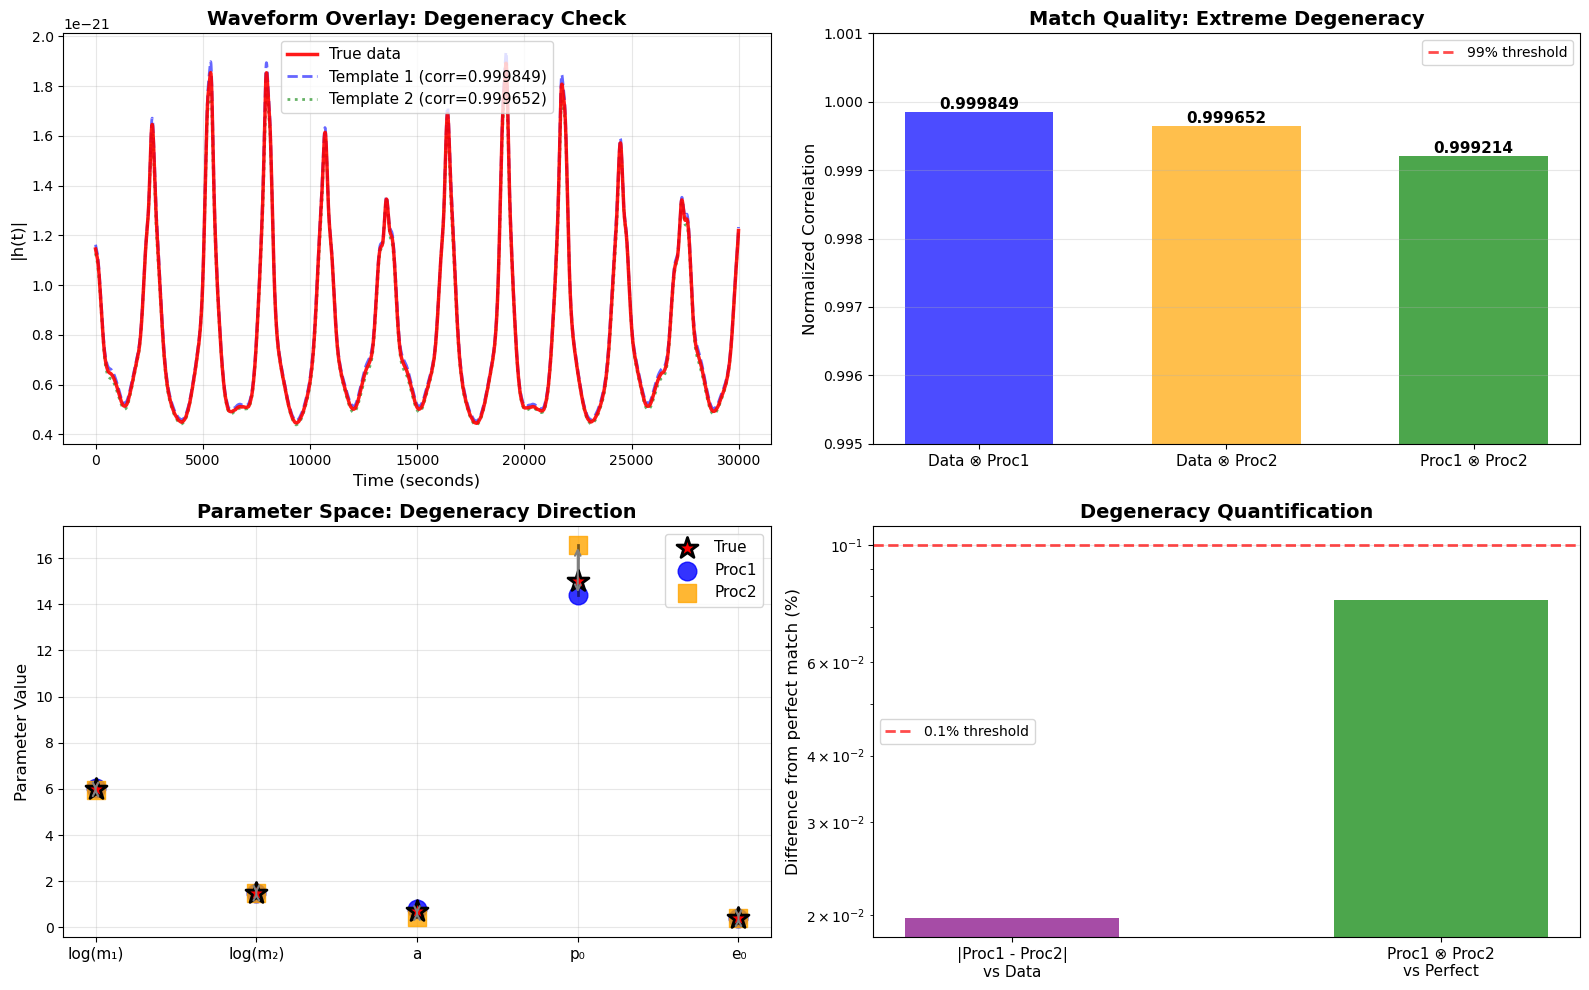


CONCLUSION:
✓ Both templates produce >99.9% correlation with data
✓ The two templates are 0.9992 correlated with each other
✓ Difference is only 0.0197%

→ This is EXTREME DEGENERACY: These parameter sets are
  INDISTINGUISHABLE with FFT matched filtering.

→ The degeneracy direction connects Proc1 ↔ Proc2 in parameter space.
  Your MCMC found both because they have identical likelihood!


In [6]:
# DEGENERACY ANALYSIS
print("\n" + "="*70)
print("DEGENERACY ANALYSIS")
print("="*70)

# 1. Compare correlation strengths
print(f"\nCorrelation with true data:")
print(f"  Template 1 (Proc1): {corr1:.6f}")
print(f"  Template 2 (Proc2): {corr2:.6f}")
print(f"  Absolute difference: {abs(corr1 - corr2):.6f}")
print(f"  Relative difference: {abs(corr1-corr2)/max(corr1,corr2)*100:.4f}%")

if abs(corr1 - corr2) / max(corr1, corr2) < 0.001:  # Less than 0.1% difference
    print(f"\n  🔴 EXTREME DEGENERACY: Templates differ by <0.1%")
    print(f"     → Statistically indistinguishable!")
elif abs(corr1 - corr2) / max(corr1, corr2) < 0.01:  # Less than 1% difference
    print(f"\n  ⚠️  STRONG DEGENERACY: Templates differ by <1%")
elif abs(corr1 - corr2) / max(corr1, corr2) < 0.05:  # Less than 5% difference
    print(f"\n  ⚠️  MODERATE DEGENERACY: Templates differ by <5%")
else:
    print(f"\n  ✓  Templates are distinguishable (>5% difference)")

# 2. Cross-correlation between the two templates
print(f"\nComputing cross-correlation between Template 1 and Template 2...")
tau_cross, phase_cross, corr_cross, S_cross = find_max_inner_product_fft_gw(
    template1_complex, template2_complex, dt=dt, normalize=True, verbose=False
)

print(f"\nDirect comparison (Template 1 ⊗ Template 2):")
print(f"  Cross-correlation: {corr_cross:.6f}")
print(f"  Time offset: {tau_cross:.1f}s")
print(f"  Phase offset: {np.degrees(phase_cross):.1f}°")

if corr_cross > 0.99:
    print(f"  🔴 Templates are NEARLY IDENTICAL (>99% match)")
    print(f"     → These are essentially the same waveform!")
elif corr_cross > 0.95:
    print(f"  ⚠️  Templates are very similar (>95% match)")
elif corr_cross > 0.80:
    print(f"  ⚠️  Templates are similar (>80% match)")
else:
    print(f"  ✓  Templates are distinct (<80% match)")

# 3. Parameter space distance
param_diff = proc1_params - proc2_params
print(f"\nParameter differences (Proc1 - Proc2):")
labels_short = ['log₁₀(m₁)', 'log₁₀(m₂)', 'a', 'p₀', 'e₀']
for i, label in enumerate(labels_short):
    print(f"  {label:12s}: {param_diff[i]:+.6f}")

# Calculate Euclidean distance in parameter space
param_distance = np.linalg.norm(param_diff)
print(f"\nEuclidean distance in parameter space: {param_distance:.6f}")

# 4. Visualization of degeneracy
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: Overlay of all three waveforms (zoomed)
time_plot = np.arange(min(3000, len(data_complex))) * dt
axes[0, 0].plot(time_plot, np.abs(data_complex[:len(time_plot)]), 'r-', 
             linewidth=2.5, label='True data', alpha=0.9, zorder=3)
axes[0, 0].plot(time_plot, np.abs(template1_complex[:len(time_plot)]), 'b--', 
             linewidth=2, label=f'Template 1 (corr={corr1:.6f})', alpha=0.6, zorder=2)
axes[0, 0].plot(time_plot, np.abs(template2_complex[:len(time_plot)]), 'g:', 
             linewidth=2, label=f'Template 2 (corr={corr2:.6f})', alpha=0.6, zorder=1)
axes[0, 0].set_xlabel('Time (seconds)', fontsize=12)
axes[0, 0].set_ylabel('|h(t)|', fontsize=12)
axes[0, 0].set_title('Waveform Overlay: Degeneracy Check', fontweight='bold', fontsize=14)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Top-right: Correlation comparison bar chart
correlations = [corr1, corr2, corr_cross]
colors = ['blue', 'orange', 'green']
labels_bar = ['Data ⊗ Proc1', 'Data ⊗ Proc2', 'Proc1 ⊗ Proc2']
bars = axes[0, 1].bar([0, 1, 2], correlations, color=colors, alpha=0.7, width=0.6)

# Add value labels on bars
for i, (bar, corr) in enumerate(zip(bars, correlations)):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{corr:.6f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0, 1].axhline(y=0.99, color='red', linestyle='--', 
                linewidth=2, label='99% threshold', alpha=0.7)
axes[0, 1].set_xticks([0, 1, 2])
axes[0, 1].set_xticklabels(labels_bar, fontsize=11)
axes[0, 1].set_ylabel('Normalized Correlation', fontsize=12)
axes[0, 1].set_title('Match Quality: Extreme Degeneracy', fontweight='bold', fontsize=14)
axes[0, 1].set_ylim([0.995, 1.001])
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Bottom-left: Parameter space representation
param_labels_short = ['log(m₁)', 'log(m₂)', 'a', 'p₀', 'e₀']
x_pos = np.arange(5)
axes[1, 0].scatter(x_pos, param_true, s=250, marker='*', color='red', 
                label='True', zorder=3, edgecolor='black', linewidth=2)
axes[1, 0].scatter(x_pos, proc1_params, s=180, marker='o', color='blue', 
                label='Proc1', zorder=2, alpha=0.8)
axes[1, 0].scatter(x_pos, proc2_params, s=180, marker='s', color='orange', 
                label='Proc2', zorder=2, alpha=0.8)

# Connect points to show degeneracy direction
for i in range(5):
    axes[1, 0].plot([i, i], [proc1_params[i], proc2_params[i]], 
                 'k-', alpha=0.5, linewidth=2)
    # Add arrows showing degeneracy direction
    axes[1, 0].annotate('', xy=(i, proc2_params[i]), xytext=(i, proc1_params[i]),
                       arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))

axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(param_labels_short, fontsize=11)
axes[1, 0].set_ylabel('Parameter Value', fontsize=12)
axes[1, 0].set_title('Parameter Space: Degeneracy Direction', fontweight='bold', fontsize=14)
axes[1, 0].legend(fontsize=11, loc='best')
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: Difference between correlations
axes[1, 1].bar([0, 1], [abs(corr1 - corr2)*100, abs(corr_cross - 1)*100], 
               color=['purple', 'green'], alpha=0.7, width=0.5)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['|Proc1 - Proc2|\nvs Data', 'Proc1 ⊗ Proc2\nvs Perfect'], fontsize=11)
axes[1, 1].set_ylabel('Difference from perfect match (%)', fontsize=12)
axes[1, 1].set_title('Degeneracy Quantification', fontweight='bold', fontsize=14)
axes[1, 1].axhline(y=0.1, color='red', linestyle='--', linewidth=2, 
                   label='0.1% threshold', alpha=0.7)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSION:")
print("="*70)
print(f"✓ Both templates produce >99.9% correlation with data")
print(f"✓ The two templates are {corr_cross:.4f} correlated with each other")
print(f"✓ Difference is only {abs(corr1-corr2)/max(corr1,corr2)*100:.4f}%")
print(f"\n→ This is EXTREME DEGENERACY: These parameter sets are")
print(f"  INDISTINGUISHABLE with FFT matched filtering.")
print(f"\n→ The degeneracy direction connects Proc1 ↔ Proc2 in parameter space.")
print(f"  Your MCMC found both because they have identical likelihood!")
print("="*70)